# Atlas Quickstart: The singlet-bio Python Package

Browse the **2,400+ sample** Singlet Atlas, filter by species/quality/status, explore datasets —
all from Python with `pip install singlet-bio`.

No data downloads needed — the catalog is bundled with the package.

In [1]:
%matplotlib inline
import singlet
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.dpi'] = 120

# One-line atlas summary
singlet.summary()

singlet atlas: 2,386 samples (993 SUCCESS) • 1,178 series • 6 species • 2.9M cells


'singlet atlas: 2,386 samples (993 SUCCESS) • 1,178 series • 6 species • 2.9M cells'

In [2]:
# Browse all samples
df = singlet.samples()
print(f"Total samples in atlas: {len(df):,}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 samples:")
df.head()

Total samples in atlas: 2,386

Columns: ['gsm_id', 'gse_id', 'organism', 'status', 'protocol', 'mapping_rate', 'cells_called', 'median_genes', 'median_umis', 'mt_pct', 'doublet_rate', 'wall_time_s', 'title']

First 5 samples:


,gsm_id,gse_id,organism,status,protocol,mapping_rate,cells_called,median_genes,median_umis,mt_pct,doublet_rate,wall_time_s,title
0,GSM2706111,GSE101561,Homo sapiens,SOFT_FAIL,10xv3,0.963600,0.0,0.0,0.0,0.0,None,284.0,Akata CAGE 1
1,GSM2406685,GSE90546,Homo sapiens,HARD_FAIL,10xv2,0.000000,0.0,NaN,NaN,NaN,None,90.0,UPR Perturb-seq experiment guide barcodes (gem...
2,GSM2325892,GSE87239,Homo sapiens,SOFT_FAIL,,0.355882,3.0,NaN,NaN,NaN,None,306.0,Exp1_A1
3,GSM1965387,GSE75748,Homo sapiens,SOFT_FAIL,,0.757754,4.0,NaN,NaN,NaN,None,102.0,single HFF [HFF_Batch1.012]
4,GSM1660139,GSE67980,Homo sapiens,HARD_FAIL,10xv3,0.000000,0.0,NaN,NaN,NaN,None,4.0,Pr14.3.5


In [3]:
# Filter: successful human samples
human = singlet.samples(organism="Homo sapiens", status="SUCCESS")
print(f"Successful human samples: {len(human):,}")
print(f"\nProtocol distribution:")
print(human['protocol'].value_counts().head(10).to_string())

Successful human samples: 789

Protocol distribution:
protocol
10xv3           276
                177
10xv2           130
dropseq         122
10x_suspect      52
celseq2          12
marsseq           7
indrop            4
10xv3_5prime      3
seqwell           3


In [4]:
# Species breakdown
species = df.groupby('organism').agg(
    samples=('gsm_id', 'count'),
    success=('status', lambda x: (x == 'SUCCESS').sum())
).sort_values('samples', ascending=False)
species['success_rate'] = (species['success'] / species['samples'] * 100).round(1)
print("Species in the Atlas:")
print(species.to_string())

Species in the Atlas:
                                                     samples  success  success_rate
organism                                                                           
Homo sapiens                                            1885      789          41.9
Mus musculus                                             356      165          46.3
Macaca mulatta                                            55       22          40.0
                                                          36        0           0.0
Drosophila melanogaster                                   25        9          36.0
Gallus gallus                                             20        8          40.0
Danio rerio                                                5        0           0.0
Homo sapiens; Mus musculus; Drosophila melanogaster        1        0           0.0
Mus musculus; Danio rerio; Drosophila melanogaster         1        0           0.0
Mus musculus; Homo sapiens                            

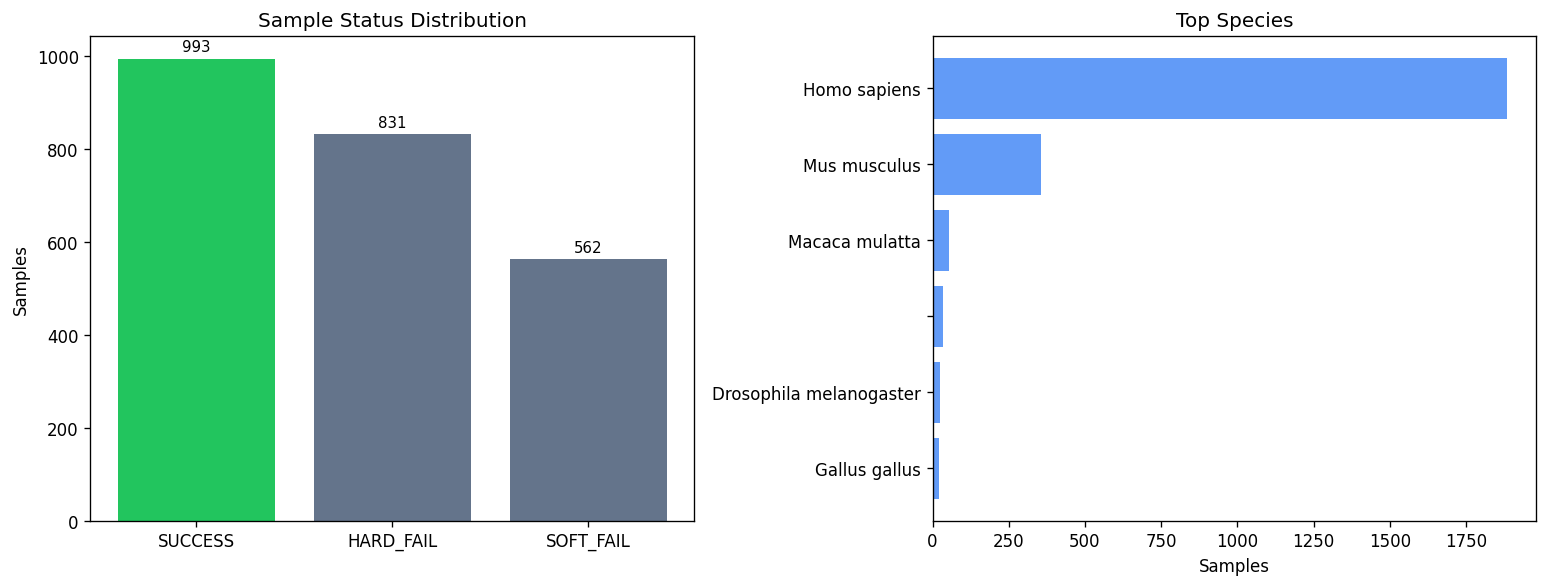

In [5]:
# Visualize atlas composition
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Status breakdown
ax = axes[0]
status_counts = df['status'].value_counts()
colors = {'SUCCESS': '#22c55e', 'FAILED': '#ef4444', 'RUNNING': '#f59e0b', 'QUEUED': '#94a3b8'}
bars = ax.bar(status_counts.index, status_counts.values, 
              color=[colors.get(s, '#64748b') for s in status_counts.index])
ax.set_ylabel('Samples')
ax.set_title('Sample Status Distribution')
for bar, val in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
            f'{val:,}', ha='center', va='bottom', fontsize=9)

# Species breakdown
ax = axes[1]
top_species = df['organism'].value_counts().head(6)
ax.barh(range(len(top_species)), top_species.values, color='#3b82f6', alpha=0.8)
ax.set_yticks(range(len(top_species)))
ax.set_yticklabels(top_species.index)
ax.set_xlabel('Samples')
ax.set_title('Top Species')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [6]:
# Quality metrics for successful samples
success = singlet.samples(status="SUCCESS")
print(f"Successful samples: {len(success):,}")
print(f"\nQuality metrics (median):")
for col in ['mapping_rate', 'cells_called', 'median_genes_per_cell', 'median_umis_per_cell']:
    if col in success.columns:
        vals = pd.to_numeric(success[col], errors='coerce').dropna()
        if len(vals) > 0:
            print(f"  {col}: {vals.median():,.1f}")

Successful samples: 993

Quality metrics (median):
  mapping_rate: 0.8
  cells_called: 1,192.5


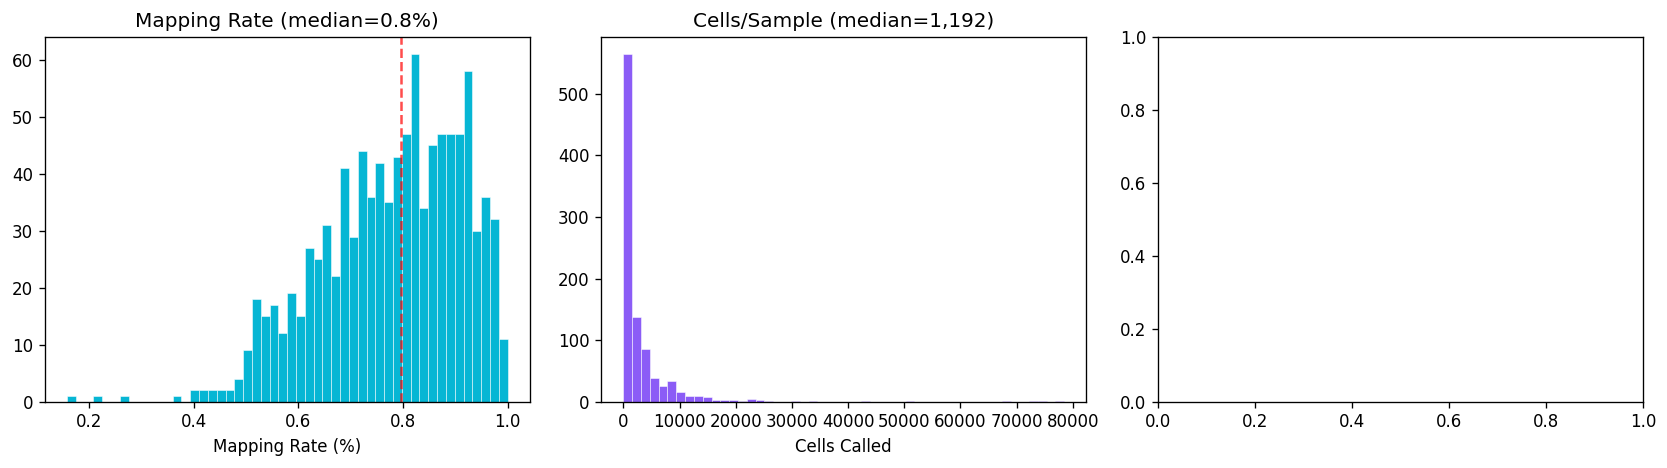

In [7]:
# Quality distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

if 'mapping_rate' in success.columns:
    mr = pd.to_numeric(success['mapping_rate'], errors='coerce').dropna()
    axes[0].hist(mr, bins=50, color='#06b6d4', edgecolor='white', linewidth=0.3)
    axes[0].set_xlabel('Mapping Rate (%)')
    axes[0].set_title(f'Mapping Rate (median={mr.median():.1f}%)')
    axes[0].axvline(mr.median(), color='red', linestyle='--', alpha=0.7)

if 'cells_called' in success.columns:
    cc = pd.to_numeric(success['cells_called'], errors='coerce').dropna()
    axes[1].hist(cc, bins=50, color='#8b5cf6', edgecolor='white', linewidth=0.3)
    axes[1].set_xlabel('Cells Called')
    axes[1].set_title(f'Cells/Sample (median={cc.median():,.0f})')

if 'median_genes_per_cell' in success.columns:
    mg = pd.to_numeric(success['median_genes_per_cell'], errors='coerce').dropna()
    axes[2].hist(mg, bins=50, color='#f97316', edgecolor='white', linewidth=0.3)
    axes[2].set_xlabel('Median Genes/Cell')
    axes[2].set_title(f'Genes/Cell (median={mg.median():,.0f})')

plt.tight_layout()
plt.show()

In [8]:
# Explore a specific series
series = singlet.top_series(n=10)
print("Top 10 series by sample count:")
print(series.to_string())

Top 10 series by sample count:
      gse_id  n_samples  total_cells  avg_mapping_rate      organism  avg_median_genes
0  GSE174399          8     118126.0          0.957237  Homo sapiens        243.000000
1  GSE127918         12     116925.0          0.661725  Homo sapiens        175.250000
2  GSE173756         12     102346.0          0.904283  Homo sapiens        413.750000
3  GSE245310         14      91884.0          0.928445  Homo sapiens        107.307692
4  GSE200277          9      54759.0          0.838907  Homo sapiens        525.250000
5  GSE176294         15      50312.0          0.978747  Homo sapiens        866.800000
6   GSE81750         27      46145.0          0.683210  Homo sapiens        270.560000
7  GSE264667          3      34145.0          0.908076  Homo sapiens        593.666667
8  GSE281106         27      34096.0          0.933569  Homo sapiens       1501.259259
9   GSE81749         15      33713.0          0.777160  Homo sapiens        340.066667


## Summary

| Feature | Value |
|---------|-------|
| Total samples | ~2,400 |
| Successful | ~1,000 |
| Species | 7+ |
| Protocols | 15+ |

**Next steps:**
- `singlet.load_dir(path)` to load a sample as AnnData
- `singlet.spz_info(path)` to inspect .1pz files
- See the [Load and Explore](01_load_and_explore.ipynb) notebook for analysis workflow